# Implement simple overfit and fix it.

In [32]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")


In [2]:
# 2 dummy numpy arrays

X = np.arange(1, 21).reshape(20,1)
y = np.array([12, 12, 19, 17, 23, 29, 25, 33, 33, 40, 38, 44, 50, 46, 54, 54, 61, 59, 65, 71])

print("X",X.shape)
print("y",y.shape)

X (20, 1)
y (20,)


In [3]:
# Split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.30, random_state = 42)

In [4]:
training_sizes = [4, 6, 8, 10, 12, 14]
train_errors = []
test_errors = []

In [ ]:
# overfit the loop with degree=8

for size in training_sizes:
    X_slice = X_train[:size]
    y_slice = y_train[:size]

    # Using Polunomial features on each training points (on training data)
    poly = PolynomialFeatures(degree=8)
    X_slice_poly = poly.fit_transform(X_slice)
    X_test_poly = poly.transform(X_test)

    # Training the points with linear regression
    model = LinearRegression()
    model.fit(X_slice_poly, y_slice)

    # predict on train & test data
    train_pred = model.predict(X_slice_poly)
    test_pred = model.predict(X_test_poly)

    train_errors.append(mean_squared_error(y_slice, train_pred))
    test_errors.append(mean_squared_error(y_test, test_pred))

print("Train errors", train_errors)
print("Test errors", test_errors)

Train errors [1.1667883876942941e-25, 2.854359184369798e-23, 9.076784796549152e-18, 1.6779006349842038, 2.9429273989184748, 3.8966734709353688]
Test errors [46.148955518026206, 86.29874027337122, 36.535100741283536, 9898.438803362153, 6830.725103539524, 1310.9554768414453]


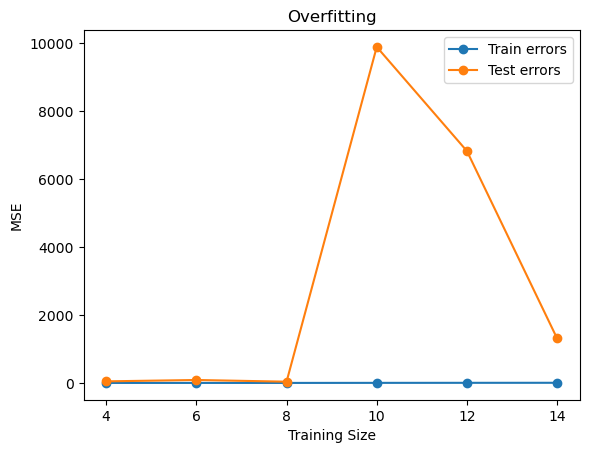

In [ ]:
# Plt the curve, for each training size plot the MSE

plt.plot(training_sizes, train_errors, label='Train errors', marker='o')
plt.plot(training_sizes, test_errors, label='Test errors', marker='o')
plt.xlabel("Training Size")
plt.ylabel("MSE")
plt.title("Overfitting")
plt.legend()
plt.show()

# Ridge (L2)- Regularization

In [ ]:
# Fix the above curve with Ridge (L2)

train_errors_ridge = []
test_errors_ridge = []


for size in training_sizes:
    X_slice = X_train[:size]
    y_slice = y_train[:size]

    poly = PolynomialFeatures(degree=8)
    X_slice_poly = poly.fit_transform(X_slice)
    X_test_poly = poly.transform(X_test)

    # Applying Ridge Model
    ridge_model = Ridge(alpha=10)
    ridge_model.fit(X_slice_poly, y_slice)

    train_pred = ridge_model.predict(X_slice_poly)
    test_pred = ridge_model.predict(X_test_poly)

    train_errors_ridge.append(mean_squared_error(y_slice, train_pred))
    test_errors_ridge.append(mean_squared_error(y_test, test_pred))

print("Train errors", train_errors_ridge)
print("Test errors", test_errors_ridge)

Train errors [3.073431723322537e-11, 0.6812240710263948, 5.77162617096074, 3.103827193296186, 3.8561181377105336, 4.0703792689031095]
Test errors [46.14896427975558, 28.538069571312644, 22.60061382164693, 22.823950550436532, 18.365891281914944, 26.441875923878985]


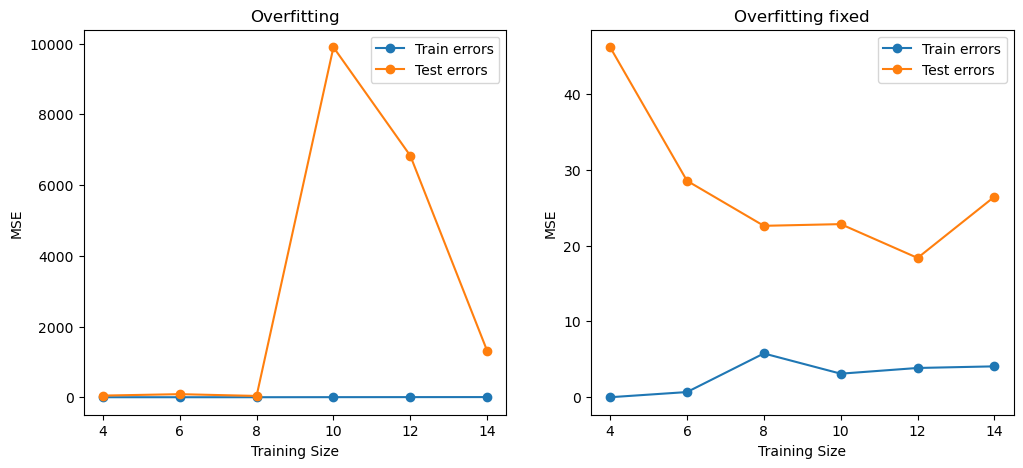

In [ ]:
#Plot graphs sidde by side

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(training_sizes, train_errors, label='Train errors', marker='o')
axs[0].plot(training_sizes, test_errors, label='Test errors', marker='o')
axs[0].set_xlabel("Training Size")
axs[0].set_ylabel("MSE")
axs[0].set_title("Overfitting")
axs[0].legend()


# Ridge graph
axs[1].plot(training_sizes, train_errors_ridge, label='Train errors', marker='o')
axs[1].plot(training_sizes, test_errors_ridge, label='Test errors', marker='o')
axs[1].set_xlabel("Training Size")
axs[1].set_ylabel("MSE")
axs[1].set_title("Overfitting fixed")
axs[1].legend()

plt.show()

In [30]:
# The left graph shows that model memorized the training data and provided close to 0 MSE. And when tested on unseen data, it had very large errors , showing Overfitting

#  The right graph used Ridge for imporving the curve. The blue line shows that Ridge has punished the errors, hence the change in MSE for taining data. Also, for test data, the MSE drops as the training size increases, which shows that model is trying to be better. Also, the gap is less between 2 lines

# L1- Lasso Regularization

In [33]:
# Fix the above curve with Ridge (L2)

train_errors_lasso = []
test_errors_lasso = []


for size in training_sizes:
    X_slice = X_train[:size]
    y_slice = y_train[:size]

    poly = PolynomialFeatures(degree=8)
    X_slice_poly = poly.fit_transform(X_slice)
    X_test_poly = poly.transform(X_test)

    # Applying Lasso Model
    lasso_model = Lasso(alpha=1.0)
    lasso_model.fit(X_slice_poly, y_slice)

    train_pred = lasso_model.predict(X_slice_poly)
    test_pred = lasso_model.predict(X_test_poly)

    train_errors_lasso.append(mean_squared_error(y_slice, train_pred))
    test_errors_lasso.append(mean_squared_error(y_test, test_pred))

print("Train errors", train_errors_lasso)
print("Test errors", test_errors_lasso)

Train errors [0.0028513869138508227, 3.8136010565642913, 4.636211952408642, 4.562819815242963, 4.9003849260346515, 4.805399941215552]
Test errors [15.096838664300302, 16.468172395808182, 10.024753508258174, 10.321619815788864, 11.262269866767086, 11.594909344680707]


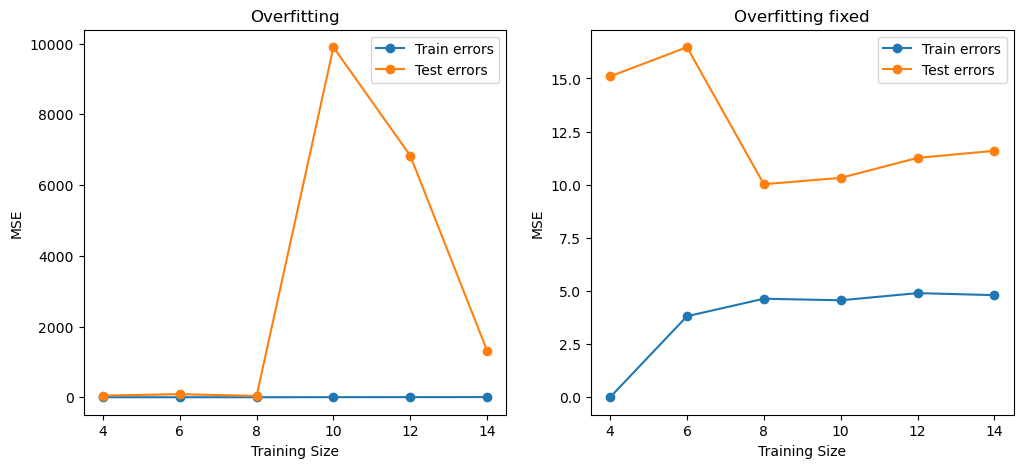

In [34]:
#Plot graphs sidde by side

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(training_sizes, train_errors, label='Train errors', marker='o')
axs[0].plot(training_sizes, test_errors, label='Test errors', marker='o')
axs[0].set_xlabel("Training Size")
axs[0].set_ylabel("MSE")
axs[0].set_title("Overfitting")
axs[0].legend()


# Ridge graph
axs[1].plot(training_sizes, train_errors_lasso, label='Train errors', marker='o')
axs[1].plot(training_sizes, test_errors_lasso, label='Test errors', marker='o')
axs[1].set_xlabel("Training Size")
axs[1].set_ylabel("MSE")
axs[1].set_title("Overfitting fixed")
axs[1].legend()

plt.show()

# To fix overfit we use L1 & L2 Regularization

- L1 - Lasso - Penalty: sum of absolute coefficients

- L2 - Ridge - Penalty: sum of squared coefficients


- When to use which Regularization?

- Use Ridge : When you believe all your features are imp and want to control their size. Ridge will keep all the features
eg: House price prediction

- Use Lasso: when you feel not all the features are important , so Lasso will auto-select the features 